#### 14-Nedan ser vi en början till modellering av ett dataset kopplat till diabetes. Läs på vad datasetet innebär och genomför ett komplett ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om du önskar försöka förbättra resultatet.


In [29]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
import matplotlib.pyplot as plt

In [30]:

data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### Datasetet innehåller 442 diabetespatienter. X är tio standardiserade
### medicinska mätvärden och y är ett kvantitativt mått på sjukdomens utveckling.

In [31]:
X, y = load_diabetes(return_X_y=True, as_frame=True) 
print(X.info()) 
print(y.info())

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None
<class 'pandas.Series'>
RangeIndex: 442 entries, 0 to 441
Series name: target
Non-Null Count  Dtype  
--------------  -----  
442 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB
None


### Inga saknade värden.
### Datatyp är bara float64 "Nomeriska värden - både X och y"

In [32]:
# Dela upp data så att testdata inte används vid träning.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:

# Grundmodell: linjär regression passar eftersom målet är koneruierligt numeriskt värde.
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 42.79
RMSE: 53.85
R²: 0.45


     Important target value  Predicted value
287                   219.0       139.547558
211                    70.0       179.517208
72                    202.0       134.038756
321                   230.0       291.417029
73                    111.0       123.789659
418                    84.0        92.172347
367                   242.0       258.232389
354                   272.0       181.337321
281                    94.0        90.224113
148                    96.0       108.633759


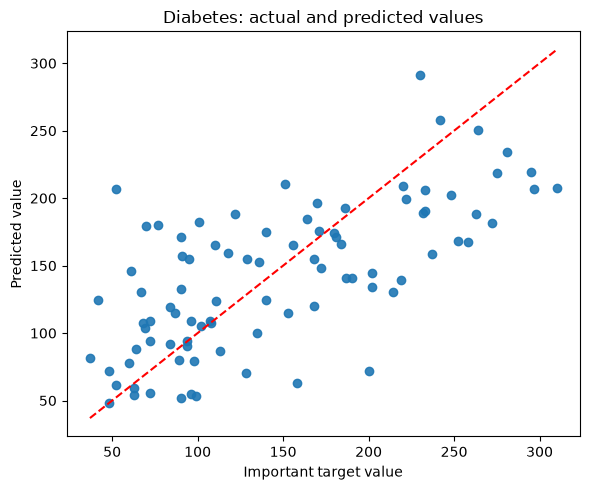

In [34]:

# Enkel kontroll av modellens prediktioner.
results = y_test.to_frame(name="Important target value")
results["Predicted value"] = y_pred
print(results.head(10))

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.9)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Important target value")
plt.ylabel("Predicted value")
plt.title("Diabetes: actual and predicted values")
plt.tight_layout()
plt.show()

In [35]:
# Jämför modeller med korsvalidering på träningsdata.
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
}

cv_rows = []
for name, candidate in models.items():
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring=scoring)
    cv_rows.append({
        "Model": name,
        "CV R2": scores["test_R2"].mean(),
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
    })

cv_results = (
    __import__("pandas").DataFrame(cv_rows)
    .sort_values("CV R2", ascending=False)
    .reset_index(drop=True)
)
print("Korsvalidering på träningsdata:")
print(cv_results.round(3).to_string(index=False))

best_name = cv_results.loc[0, "Model"]
best_model = models[best_name]
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

print(f"\nBästa modell enligt CV: {best_name}")
print(f"Test MAE: {mean_absolute_error(y_test, best_pred):.2f}")
print(f"Test RMSE: {mean_squared_error(y_test, best_pred) ** 0.5:.2f}")
print(f"Test R²: {r2_score(y_test, best_pred):.2f}")

Korsvalidering på träningsdata:
           Model  CV R2  CV MAE  CV RMSE
LinearRegression  0.480  45.048   55.395
    RandomForest  0.425  47.665   58.119
           Ridge  0.113  62.287   72.611

Bästa modell enligt CV: LinearRegression
Test MAE: 42.79
Test RMSE: 53.85
Test R²: 0.45
